# 笔者运行环境
OS: Ubuntu 22.04.1 LTS

Python: 3.12.9

PyTorch: 2.6.0+cu124

In [6]:
import logging
# 配置日志
logging.basicConfig(
    level=logging.DEBUG,
    format='[%(levelname)s] %(asctime)s %(funcName)s:%(lineno)d :: %(message)s',
    handlers=[
        logging.StreamHandler(),  # 控制台输出
        #logging.FileHandler('notebook.log')  # 文件输出
    ]
)
logger = logging.getLogger("JupyterDemo")


# 数据集处理

## 安装kagglehub

In [7]:
%pip install kagglehub

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


## 把数据集建立一个软连接到当前目录


In [8]:
!ln -s ~/.cache/kagglehub/datasets/ ./ -f

## 下载数据集
找到kaggle上有一个其他人分享的CNN识别骨科影像（X光片）的项目，https://www.kaggle.com/code/ahmedashrafahmed/bone-fracture-classification-using-cnn
不过我们只用他的数据集

In [9]:
import kagglehub
# 默认下载到  ~/.cache/kagglehub/datasets/ 目录中
ahmedashrafahmed_bone_fracture_path = kagglehub.dataset_download('ahmedashrafahmed/bone-fracture')

print(f'Data source import complete. {ahmedashrafahmed_bone_fracture_path}')


[DEBUG] 2025-05-02 13:27:03,824 _new_conn:1049 :: Starting new HTTPS connection (1): www.kaggle.com:443
[DEBUG] 2025-05-02 13:27:04,655 _make_request:544 :: https://www.kaggle.com:443 "GET /api/v1/datasets/view/ahmedashrafahmed/bone-fracture HTTP/1.1" 200 None


Data source import complete. /home/guodong/.cache/kagglehub/datasets/ahmedashrafahmed/bone-fracture/versions/1


## 自定义Dataset类
即数据集解析处理类

In [22]:
import os
#import pandas as pd
from torch.utils.data import Dataset
from torchvision.io import read_image
import os

class CustomImageDataset(Dataset):
    def __init__(self, img_dir, transform=None, target_transform=None):
        logger.info(f"img_dir: {img_dir}")
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
        self.flat_img = []
        for root, dirs, files in os.walk(self.img_dir):
            for dir in dirs:
                dir_path = os.path.join(root, dir)
                for root_, dirs_, files_ in os.walk(dir_path):
                    logger.info(f"label:{dir} image count: {len(files_)}")
                    for file in files_:
                        if file.endswith(".jpg"):
                            self.flat_img.append([os.path.join(root_, file), dir])
        logger.info(f"flat_img[:5]: {self.flat_img[:5]}")

    def __len__(self):
        """
        数据集的样本数量
        """
        return len(self.flat_img)

    def __getitem__(self, idx):
        # logger.info(f"idx: {idx}")
        img_path, label = self.flat_img[idx]
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

    def get_image(self, idx):
        """
        调试用的，非必须
        """
        if idx >= len(self.flat_img):
            logger.error(f"invalid idx:{idx} len is {len(self.flat_img)}")
            return ""
        return self.flat_img[idx][0]

## 定义转换函数
transfrom函数用来归一化原始图像数据；target_transform用来归一化原始标签数据

In [11]:
from torchvision.transforms import v2
from torchvision import transforms
from torchvision.io import read_image

transform = v2.Compose([
    v2.Resize((224, 224)),  # 强制统一尺寸
    transforms.Grayscale(num_output_channels=1),  # 强制转单通道
    v2.ToTensor()
])



class CustomTransform:
    def __call__(self, x):
        transform = v2.Compose([
            v2.Resize((224, 224)),  # 强制统一尺寸
            transforms.Grayscale(num_output_channels=1),  # 强制转单通道
            v2.ToTensor()
        ])
        x = transform(x)
        # x dtype是 uint8，转成float并归一化到 [0.0, 1.0] 区间
        x = x.float() / 255.0
        return transform(x)

class CustomTargetTransform:
    def __call__(self, y):
        if y == 'fractured':
            return torch.tensor([1.0])  # dtype为float
        else:
            return torch.tensor([0.0])

transform = CustomTransform()
target_transform = CustomTargetTransform()

/home/guodong/miniconda3/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [23]:
train_data = CustomImageDataset(ahmedashrafahmed_bone_fracture_path + "/dataset/train", transform, target_transform)
test_data = CustomImageDataset(ahmedashrafahmed_bone_fracture_path + "/dataset/test", transform, target_transform)
val_data = CustomImageDataset(ahmedashrafahmed_bone_fracture_path + "/dataset/val", transform, target_transform)
print(f"train data: {len(train_data)}, test data: {len(test_data)}, val data: {len(val_data)}")

train data: 4097, test data: 399, val data: 404


## 从Dataset构造DataLoader

In [13]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True)

# 模型
定义一个神经网络模型类，用于图像分类任务

In [14]:
import torch
import torch.nn as nn

class MyModel(nn.Module):
    def __init__(self, class_num=1):
        super(MyModel, self).__init__()
        
        # 卷积块1 (对应Keras第一层)
        self.conv_block1 = nn.Sequential(
            # nn.Conv2d(3, 32, kernel_size=3, stride=1, padding='same'),  # 输入通道3，输出32，padding保持空间维度
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding='same'),  # 输入通道1，输出32，padding保持空间维度
            nn.BatchNorm2d(32),  # 批归一化层，特征数需匹配卷积输出通道
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 池化窗口2x2
        )
        
        # 卷积块2
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
        )
        
        # 卷积块3
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
        )
        
        # 全连接部分
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),  # 输入维度需根据前层输出计算
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, class_num),
            nn.Sigmoid()
        )

    def forward(self, x):
        logger.info(f"{x.dtype}")
        x = self.conv_block1(x)
        logger.info(f"{x.dtype}")
        x = self.conv_block2(x)
        logger.info(f"{x.dtype}")
        x = self.conv_block3(x)
        logger.info(f"{x.dtype}")
        x = self.classifier(x)
        logger.info(f"{x.dtype}")
        return x


# 训练

## 构造模型对象

In [15]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device") 

model = MyModel().to(device)

print(f"model = {model}")


Using cuda device
model = MyModel(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4):

## 确定损失函数和优化器

In [16]:
# loss_fn = nn.CrossEntropyLoss()  # 多分类任务
loss_fn = nn.BCELoss()  # 二分类任务
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 训练函数

## 关闭info日志
在调试OK，正式开始训练的时候可以关闭info日志，减少输出和训练时间

In [17]:
logger.setLevel(logging.ERROR)

## 评估函数

In [18]:
def evaluate(model, dataloader, loss_fn):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            logger.info(f"{pred.shape}, {y.shape}")
            total_loss += loss_fn(pred, y).item()
            print(f"pred: {pred}")
            correct += ((pred > 0.5).long() == y).type(torch.float).sum().item()
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / len(dataloader.dataset)
    return avg_loss, accuracy  # 返回损失和准确率


## 训练函数

[DEBUG] 2025-05-02 13:27:07,681 wrapper:342 :: matplotlib data path: /home/guodong/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data
[DEBUG] 2025-05-02 13:27:07,694 wrapper:342 :: CONFIGDIR=/home/guodong/.config/matplotlib
[DEBUG] 2025-05-02 13:27:07,723 <module>:1557 :: interactive is False
[DEBUG] 2025-05-02 13:27:07,724 <module>:1558 :: platform is linux
[DEBUG] 2025-05-02 13:27:07,778 wrapper:342 :: CACHEDIR=/home/guodong/.cache/matplotlib
[DEBUG] 2025-05-02 13:27:07,781 _load_fontmanager:1635 :: Using fontManager instance from /home/guodong/.cache/matplotlib/fontlist-v390.json
/home/guodong/miniconda3/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


pred: tensor([[0.1049],
        [0.1826],
        [0.1358],
        [0.1208],
        [0.1314],
        [0.0777],
        [0.1363],
        [0.0749],
        [0.1305],
        [0.0908],
        [0.1589],
        [0.1142],
        [0.0723],
        [0.2754],
        [0.1531],
        [0.1793],
        [0.2316],
        [0.2217],
        [0.1848],
        [0.5858],
        [0.2476],
        [0.3076],
        [0.1965],
        [0.0982],
        [0.2255],
        [0.0579],
        [0.1987],
        [0.4339],
        [0.1263],
        [0.1898],
        [0.1480],
        [0.2869],
        [0.1325],
        [0.2956],
        [0.1564],
        [0.1197],
        [0.1453],
        [0.1787],
        [0.2342],
        [0.2003],
        [0.2125],
        [0.0501],
        [0.1101],
        [0.2414],
        [0.1826],
        [0.2645],
        [0.0564],
        [0.1955],
        [0.1687],
        [0.4044],
        [0.2483],
        [0.1223],
        [0.2626],
        [0.1488],
        [0.2111],
    

[DEBUG] 2025-05-02 13:30:50,004 switch_backend:497 :: Loaded backend module://matplotlib_inline.backend_inline version unknown.
[DEBUG] 2025-05-02 13:30:50,010 switch_backend:497 :: Loaded backend module://matplotlib_inline.backend_inline version unknown.
[DEBUG] 2025-05-02 13:30:50,018 _findfont_cached:1471 :: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
[DEBUG] 2025-05-02 13:30:50,019 _findfont_cached:1483 :: findfont: score(FontEntry(fname='/home/guodong/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG] 2025-05-02 13:30:50,021 _findfont_cached:1483 :: findfont: score(FontEntry(fname='/home/guodong/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='nor

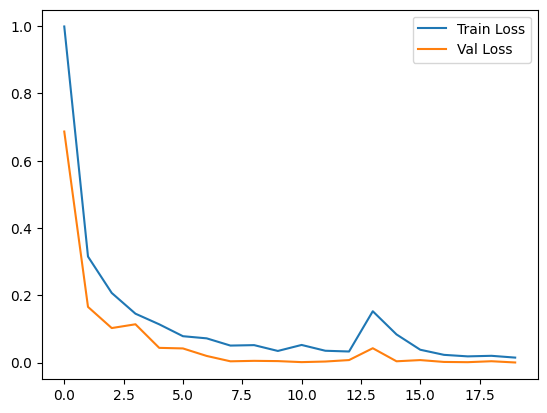

In [19]:
import matplotlib.pyplot as plt

def train(dataloader, model, loss_fn, optimizer, epochs):
    best_acc = 0.0  # 用来跟踪最佳准确率
    best_lost = 1.0 # 用来跟踪最佳损失
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(dataloader))

        # 验证阶段
        model.eval()
        val_loss = evaluate(model, val_dataloader, loss_fn)
        val_loss, val_acc = evaluate(model, val_dataloader, loss_fn)
        print(f"Epoch {epoch} Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4%}")
        if val_acc > best_acc:
            best_acc = val_acc
            print(f"[Save Model] Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4%}")
            torch.save(model.state_dict(), 'best_model.pth')
        elif val_acc == best_acc and val_loss < best_lost:
            best_lost = val_loss
            print(f"[Save Model] Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4%}")
            torch.save(model.state_dict(), 'best_model.pth')
        val_losses.append(val_loss)


    # 绘制损失曲线
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.show()

train(train_dataloader, model, loss_fn, optimizer, 20)

# 加载训练好的模型

In [20]:
classes = [
    "未骨折",
    "骨折",
]

In [24]:
best_model = MyModel().to(device)
best_model.load_state_dict(torch.load('best_model.pth', weights_only=True))
best_model.eval()
with torch.no_grad():
    for idx, (x, y) in enumerate(test_data):
        #print(f"x.shape: {x.shape} y.shape: {y.shape}")
        x = x.unsqueeze(0).to(device)
        pred = best_model(x)
        pred = pred.unsqueeze(1)
        predicted = classes[(pred > 0.5).long().item()]
        actual = classes[y.long()]
        print(f'Predicted: "{predicted}", Actual: "{actual}"')
        if predicted != actual:
            faild_image_path = test_data.get_image(idx)
            logger.error(f'"{faild_image_path} Predicted: "{predicted}", Actual: "{actual}"')


Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted: "骨折", Actual: "骨折"
Predicted:

[ERROR] 2025-05-02 13:31:50,536 <module>:15 :: "/home/guodong/.cache/kagglehub/datasets/ahmedashrafahmed/bone-fracture/versions/1/dataset/test/not fractured/57-rotated1-rotated3.jpg Predicted: "骨折", Actual: "未骨折"


Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicted: "未骨折", Actual: "未骨折"
Predicte